Transformadas de Fourier

In [ ]:
%pip install ipywidgets
#intala librerias en caso de no estar instaladas.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import widget
from IPython.display import display
from mpl_toolkits.mplot3d import Axes3D 
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

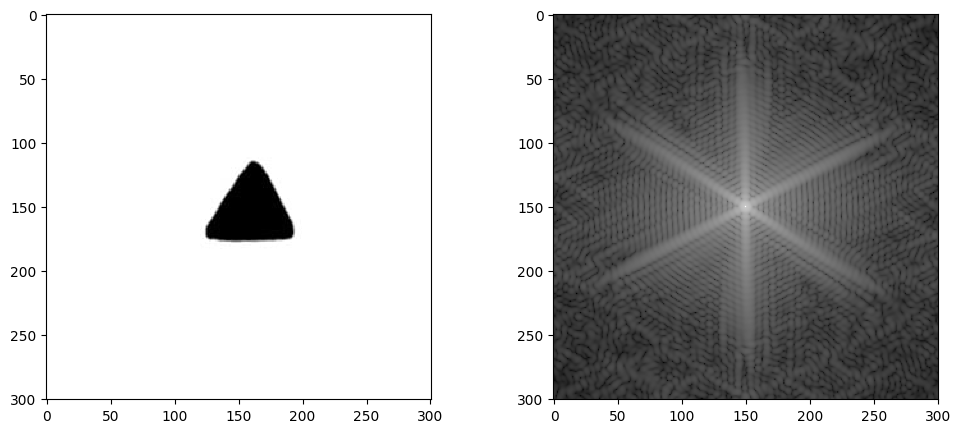

In [6]:
def get_fft(image, log=True, padding=None):
    if padding:
        fft = np.fft.fft2(image, s=padding)
    else:
        fft = np.fft.fft2(image)
    fft_shifted = np.fft.fftshift(fft) # Se mueve la frecuencia 0 (DC) al centro de la imagen
    #fft_spectrum = 20*np.log(np.abs(fft_shifted)) # Espectro - Módulo en escala logarítmica
    if log: 
        return np.log(np.abs(fft_shifted) + 1)
    return np.abs(fft_shifted)
img = cv2.imread("img/triangulo.jpg", cv2.IMREAD_GRAYSCALE)
fft_image = get_fft(img, True)
fig, axs = plt.subplots(1, 2, figsize=(12,5))
axs[0].imshow(img, cmap="gray", interpolation="nearest")
axs[1].imshow(fft_image, cmap="gray")
plt.show()

In [8]:
#Métodos de cálculo
kernel_sobel = (1/8) * np.asmatrix([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
    ], dtype=np.float32)

kernel_bilineal = (1/16) * np.asmatrix([
    [1,2,1],
    [2,4,2],
    [1,2,1]
    ], dtype=np.float32)

K = 3
kernel_box = (1/(K**2))*np.ones(shape=(K,K))

kernel_gaussian = (1/256) * np.asmatrix([
    [1,4,6,4,1],
    [4,16,24,16,4],
    [6,24,36,24,6],
    [4,16,24,16,4],
    [1,4,6,4,1]
    ],dtype=np.float32)

kernel_corner = (1/4) * np.asmatrix([
    [1,-2,1],
    [-2,4,-2],
    [1,-2,1]
    ], dtype=np.float32)

kernel_sharpening = (1/4) * np.asmatrix([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
    ], dtype=np.float32)

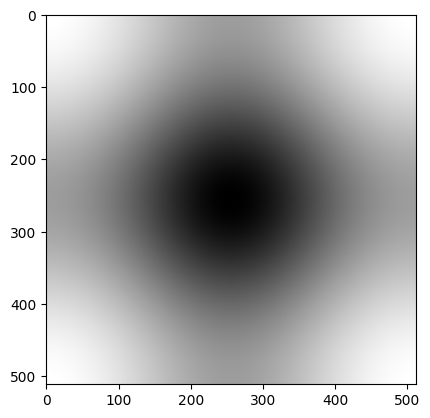

In [9]:
#Cálculo de tranformadas
filter = kernel_sharpening
fft_img = get_fft(filter, True, padding=(512,512))
plt.imshow(fft_img, cmap="gray")
plt.show()

Seno y Coseno

In [16]:
img = cv2.imread("img/triangulo.jpg", cv2.IMREAD_GRAYSCALE)
img = np.float32(img)
dct = cv2.dct(img)
dct_abs = np.abs(dct)
dct_spec = np.log(dct_abs + 1)

fft = np.fft.fft2(img)
fft_2 = np.fft.fftshift(fft)
fft_abs = np.abs(fft)
fft_spec = np.log(fft_abs + 1)

fft_abs_2 = np.abs(fft_2)
fft_spec_2 = np.log(fft_abs_2 + 1)

n,m = fft_spec.shape
fft_spec_seg = fft_spec_2[0:n//2, :]#0:m//2]

fft_phase = np.angle(fft_2)

h = ( (fft_phase + np.pi) / (2 * np.pi) * 179 ).astype(np.uint8)
s = np.uint8(255 * np.ones_like(fft_phase))
v = cv2.normalize(fft_spec_2, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

mag_phase = cv2.merge([h, s, v])
mag_phase_RGB = cv2.cvtColor(mag_phase, cv2.COLOR_HSV2RGB)

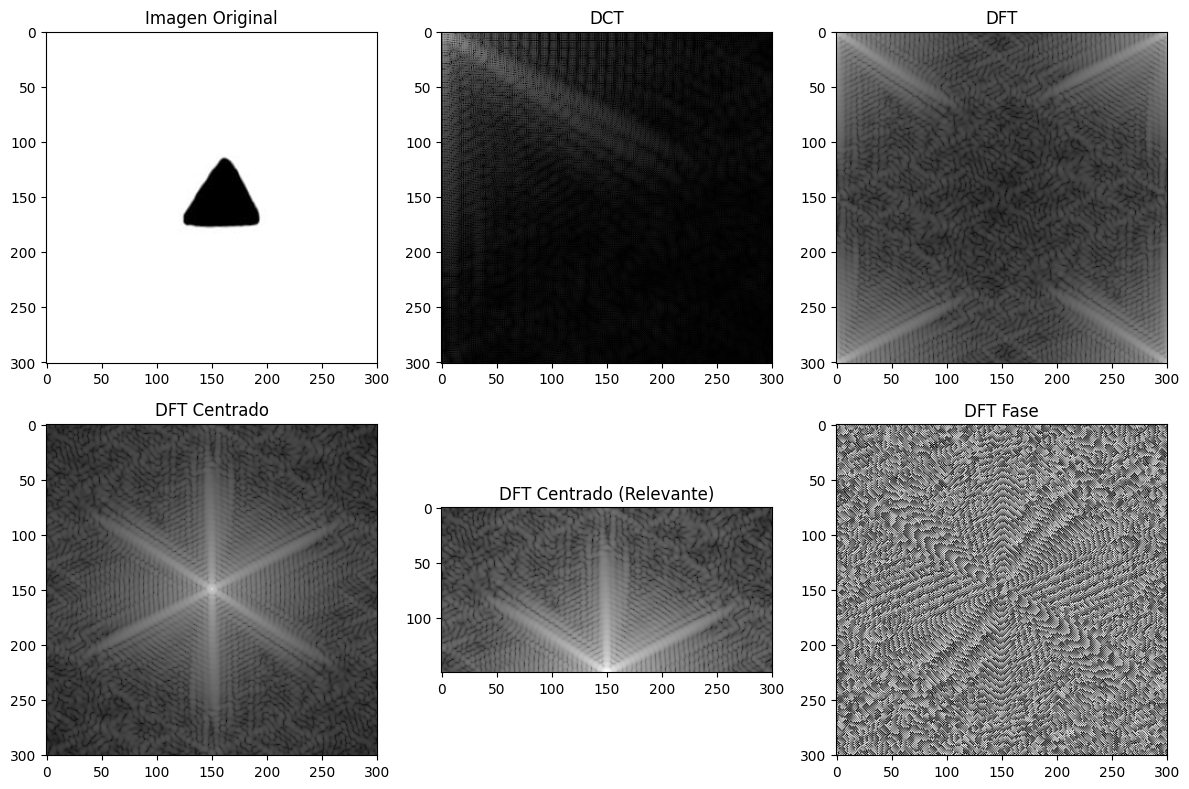

In [17]:
fig, axs = plt.subplots(2,3, figsize=(12,8))

axs[0,0].imshow(img, cmap="gray")
axs[0,0].set_title("Imagen Original")

axs[0,1].imshow(dct_spec, cmap="gray")
axs[0,1].set_title("DCT")

axs[0,2].imshow(fft_spec, cmap="gray")
axs[0,2].set_title("DFT")

axs[1,0].imshow(fft_spec_2, cmap="gray")
axs[1,0].set_title("DFT Centrado")

axs[1,1].imshow(fft_spec_seg, cmap="gray")
axs[1,1].set_title("DFT Centrado (Relevante)")

axs[1,2].imshow(fft_phase, cmap="gray")
axs[1,2].set_title("DFT Fase")

plt.tight_layout()
plt.show()

Funciones de Fourier através de la cámara

In [18]:
def spectrum(img):
    img = np.float32(img)
    img_dft =  cv2.dft(img, flags = cv2.DFT_COMPLEX_OUTPUT)
    img_dft_shifted = np.fft.fftshift(img_dft)
    img_mag = cv2.magnitude(img_dft_shifted[:,:,0], img_dft_shifted[:,:,1])
    return np.log(img_mag + 1)

# Captura desde la fuente default
camara = cv2.VideoCapture(0)

print("Oprime q para salir de la captura de camara")
while camara.isOpened():
    while True:
        ret, frame = camara.read()
        if not ret:
            print("Error al leer frame desde la cámara")
            break

        # Obtener espectro y mostrarla
        frame_y = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame_fft = spectrum(frame_y)
        
        # Se normaliza y cambia a tipo uint8. cv2.imshow necesita este formato
        # de la imagen para mostarlo (de 0 a 255)
        cv2.normalize(frame_fft, frame_fft, 0, 255, cv2.NORM_MINMAX)
        mag = np.uint8(frame_fft)
        
        frame_show = np.hstack((frame_y, mag))


        cv2.imshow("Camara", frame_show)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    break

camara.release()
cv2.destroyAllWindows()


Oprime q para salir de la captura de camara
